# Representation-level explanations for GraphKoopman models

This notebook shows how to attribute a homogeneous `GraphKoopmanModel` quantity
with `explain_representation`, inspect GNNExplainer node/edge masks on a small
path graph, and read those masks under the package honesty contract.

**Honesty banner.** Masks are **interpretive** attributions under a chosen
algorithm. They are **non-causal** (not interventional topology recovery),
**not** ResDMD residual bounds, and **not**
`ModeEnergyAttribution` (the complementary operator-level energy diagnostic on
assembled `K_eff`). The MVP is homogeneous `Data` only.


## Setup

Imports, seeds, package/torch versions, and a non-interactive Matplotlib
backend under pytest / CI.


In [1]:
import os
import random
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.analysis import explain_representation

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IS_CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
NUM_NODES = 6
IN_CHANNELS = 3
HIDDEN = 8
LATENT = 4
EPOCHS = 2 if IS_CI else 15
EXPLAIN_EPOCHS = 5 if IS_CI else 40
LR = 0.05

print(f"koopman_graph {koopman_graph.__version__}")
print(f"torch {torch.__version__}")
print(f"CI_lite={IS_CI} fit_epochs={EPOCHS} explain_epochs={EXPLAIN_EPOCHS}")


koopman_graph 0.12.0
torch 2.13.0
CI_lite=False fit_epochs=15 explain_epochs=40


## Motivation and background

Graph neural encoders mix node features with neighborhood messages, so a
forecast can depend on both local features and edge structure. Readers often
want a **compact** view of which nodes and edges the model relied on for a
chosen quantity (latent state, reconstruction, or one-step forecast).

`explain_representation` wraps PyG explainers for that purpose:

- `algorithm="gnn_explainer"` — GNNExplainer mask optimization (Ying et al.,
  NeurIPS 2019; `Ying2019GNNExplainer`); core dependency, no extra install.
- `algorithm="integrated_gradients"` — Captum integrated gradients
  (Sundararajan, Taly & Yan, ICML 2017; `Sundararajan2017IntegratedGradients`);
  requires `pip install "koopman-graph[explain]"`.

These tools produce **attribution masks**, not causal discovery. For
operator-level type/relation energy fractions on assembled `K_eff`, use
`attribute_mode_energy` instead (see
[`docs/source/capabilities.rst`](../docs/source/capabilities.rst) and
[`docs/source/limitations.rst`](../docs/source/limitations.rst)).


## Minimal example: path graph + GNNExplainer

Build a tiny homogeneous path, fit a short encode → Koopman → decode model, then
attribute `one_step_forecast` with GNNExplainer.


### Synthetic path and model

Undirected path with random node features and a small homogeneous GraphKoopman
stack.


In [2]:
def path_graph(num_nodes: int = NUM_NODES, in_channels: int = IN_CHANNELS) -> Data:
    """Undirected path with random node features."""
    sources = list(range(num_nodes - 1)) + list(range(1, num_nodes))
    targets = list(range(1, num_nodes)) + list(range(num_nodes - 1))
    edge_index = torch.tensor([sources, targets], dtype=torch.long)
    x = torch.randn(num_nodes, in_channels)
    return Data(x=x, edge_index=edge_index)


def tiny_model() -> GraphKoopmanModel:
    return GraphKoopmanModel(
        encoder=GNNEncoder(IN_CHANNELS, HIDDEN, LATENT, num_layers=2),
        decoder=GNNDecoder(LATENT, HIDDEN, IN_CHANNELS, num_layers=2),
        latent_dim=LATENT,
        time_step=0.1,
    )


def make_pair_sequence(data: Data, steps: int = 8):
    """Build a short GraphSnapshotSequence of near-identity diffusion steps."""
    from koopman_graph.data import GraphSnapshotSequence

    snaps = []
    x = data.x.clone()
    for _ in range(steps):
        snaps.append(Data(x=x.clone(), edge_index=data.edge_index.clone()))
        # Mild diffusion along the path (keeps topology fixed).
        deg = torch.zeros(x.shape[0], 1)
        src, dst = data.edge_index
        ones = torch.ones(src.shape[0], 1)
        deg.index_add_(0, src, ones)
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, x[src])
        x = 0.85 * x + 0.15 * (agg / deg.clamp_min(1.0))
    return GraphSnapshotSequence(snaps)


torch.manual_seed(SEED)
data0 = path_graph()
sequence = make_pair_sequence(data0)
model = tiny_model()
print(f"nodes={data0.num_nodes} edges={data0.num_edges} latent_dim={LATENT}")


nodes=6 edges=10 latent_dim=4


### Short fit

Train briefly so the encoder/decoder are not random weights. Under pytest /
CI the epoch count is reduced for smoke speed.


In [3]:
history = model.fit(sequence, epochs=EPOCHS, lr=LR)
print(f"final reconstruction_loss={history.reconstruction_loss[-1]:.4f}")


final reconstruction_loss=0.1688


### Attribute `one_step_forecast`

Call `explain_representation` on the first snapshot with the default
GNNExplainer algorithm.


In [4]:
snapshot = sequence[0]
explanation = explain_representation(
    model,
    snapshot,
    target="one_step_forecast",
    algorithm="gnn_explainer",
    epochs=EXPLAIN_EPOCHS,
    lr=0.05,
)
print(
    f"algorithm={explanation.algorithm!r} target={explanation.target!r}\n"
    f"node_mask shape={tuple(explanation.node_mask.shape)} "
    f"edge_mask shape={tuple(explanation.edge_mask.shape)}"
)
assert explanation.node_mask is not None and explanation.edge_mask is not None
assert explanation.node_mask.shape[0] == snapshot.num_nodes
assert explanation.edge_mask.shape[0] == snapshot.num_edges


algorithm='gnn_explainer' target='one_step_forecast'
node_mask shape=(6, 1) edge_mask shape=(10,)


## Progressive deep dive: targets and MVP rejects

The same wrapper can attribute `latent` (encoder output) or `reconstruction`
(encode → decode). Unsupported modes raise actionable errors — useful as a
guardrail when a notebook later grows hetero / delay / control complexity.


In [5]:
for target in ("latent", "reconstruction", "one_step_forecast"):
    result = explain_representation(
        model,
        snapshot,
        target=target,
        algorithm="gnn_explainer",
        epochs=EXPLAIN_EPOCHS,
        lr=0.05,
    )
    node_abs = result.node_mask.detach().abs().mean().item()
    edge_abs = result.edge_mask.detach().abs().mean().item()
    print(
        f"{target:18s}  mean|node|={node_abs:.4f}  mean|edge|={edge_abs:.4f}"
    )

# MVP reject: delay embedding is out of scope.
delay_model = GraphKoopmanModel(
    encoder=GNNEncoder(IN_CHANNELS * 2, HIDDEN, LATENT, num_layers=2),
    decoder=GNNDecoder(LATENT, HIDDEN, IN_CHANNELS, num_layers=2),
    latent_dim=LATENT,
    time_step=0.1,
    n_delays=2,
)
try:
    explain_representation(delay_model, snapshot, epochs=1)
except ValueError as exc:
    print(f"expected reject: {exc}")


latent              mean|node|=0.1309  mean|edge|=0.4081
reconstruction      mean|node|=0.1413  mean|edge|=0.4981
one_step_forecast   mean|node|=0.1418  mean|edge|=0.4989
expected reject: explain_representation supports n_delays=1 only (got n_delays=2)


### Optional Captum integrated gradients

`algorithm="integrated_gradients"` typically returns `(N, F)` feature-attribute
masks with `edge_mask=None`. Skip this cell unless the `[explain]` extra is
installed (`pip install "koopman-graph[explain]"`).


In [6]:
try:
    import captum  # noqa: F401
except ImportError:
    print('Captum not installed; skip IG demo. Install with: pip install "koopman-graph[explain]"')
else:
    ig = explain_representation(
        model,
        snapshot,
        target="one_step_forecast",
        algorithm="integrated_gradients",
        index=0,
    )
    print(
        f"IG node_mask shape={tuple(ig.node_mask.shape)} "
        f"feature_mask shape={tuple(ig.feature_mask.shape)} "
        f"edge_mask={ig.edge_mask}"
    )


IG node_mask shape=(6, 3) feature_mask shape=(6, 3) edge_mask=None


## Results

Plot absolute GNNExplainer masks for the `one_step_forecast` explanation above.
On this under-trained path, expect **near-uniform** node `|mask|` bars and
**uneven** edge `|mask|` mass concentrated on a few directed edges (the printed
top indices name the peaks for this seeded run). Read those peaks as explainer
diagnostics — **relative** contrast only, not absolute importance scores and
not a causal ranking of nodes or edges.


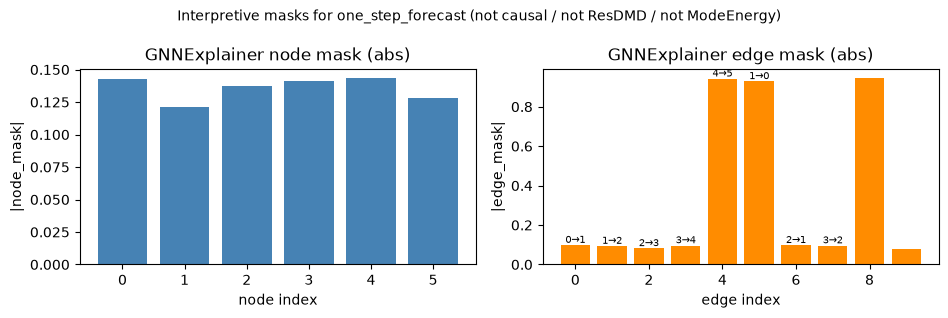

top node by |mask|: 4 top edge by |mask|: 8 (4→3)
node |mask| range: [0.122, 0.144]; edge |mask| range: [0.078, 0.946]


In [7]:
node_w = explanation.node_mask.detach().cpu().squeeze(-1).numpy()
edge_w = explanation.edge_mask.detach().cpu().numpy()
src, dst = snapshot.edge_index.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))

axes[0].bar(np.arange(len(node_w)), np.abs(node_w), color="steelblue")
axes[0].set_xlabel("node index")
axes[0].set_ylabel("|node_mask|")
axes[0].set_title("GNNExplainer node mask (abs)")

axes[1].bar(np.arange(len(edge_w)), np.abs(edge_w), color="darkorange")
axes[1].set_xlabel("edge index")
axes[1].set_ylabel("|edge_mask|")
axes[1].set_title("GNNExplainer edge mask (abs)")
for i, (u, v) in enumerate(zip(src, dst)):
    if i < 8:  # annotate a few for readability
        axes[1].text(i, abs(edge_w[i]), f"{u}→{v}", ha="center", va="bottom", fontsize=7)

fig.suptitle(
    "Interpretive masks for one_step_forecast (not causal / not ResDMD / not ModeEnergy)",
    fontsize=10,
)
fig.tight_layout()
plt.show()

top_node = int(np.argmax(np.abs(node_w)))
top_edge = int(np.argmax(np.abs(edge_w)))
print(
    "top node by |mask|:",
    top_node,
    "top edge by |mask|:",
    top_edge,
    f"({src[top_edge]}→{dst[top_edge]})",
)
print(
    f"node |mask| range: [{np.abs(node_w).min():.3f}, {np.abs(node_w).max():.3f}]; "
    f"edge |mask| range: [{np.abs(edge_w).min():.3f}, {np.abs(edge_w).max():.3f}]"
)


## Interpretation / discussion

On this tiny path, masks fluctuate with initialization, explainer epochs, and
the short fit — treat them as a **diagnostic view** of the explainer's
optimization under the chosen target, not as ground-truth importance. Flat
node bars with a few large edge bars are common on under-trained synthetic
fixtures; that pattern is evidence about the explainer run, not a recovered
communication pathway.

Complementary diagnostics:

| Tool | Level | Claim type |
|------|-------|------------|
| `explain_representation` | node / edge / feature masks | interpretive, non-causal |
| `attribute_mode_energy` | type/relation energy on `K_eff` | interpretive operator energy |
| `spectral_residuals` / `resdmd` | residual diagnostics | data-driven / fixed-dictionary residuals — not this API |

The optional Captum path above (`algorithm="integrated_gradients"`) is for
feature-attribute masks when `[explain]` is installed; it does not replace
GNNExplainer edge masks or ModeEnergy / ResDMD diagnostics.


## Takeaways

- Use `explain_representation` for **homogeneous** snapshot masks on
  `latent` / `reconstruction` / `one_step_forecast`.
- Default `gnn_explainer` needs no extra; `integrated_gradients` needs
  `[explain]` (Captum).
- Masks are **interpretive** and **non-causal** — not topology discovery, not
  ResDMD, not `ModeEnergyAttribution`.
- MVP rejects hetero / RelGraph / hypergraph / adaptive topology / delays /
  controls; expect actionable errors rather than silent fallbacks.
- Prefer short synthetic fixtures for teaching; do not over-claim mask contrast
  on under-trained models.


## Further reading

- Ying, Z., Bourgeois, D., You, J., Zitnik, M. & Leskovec, J. (2019).
  GNNExplainer: Generating Explanations for Graph Neural Networks.
  *Advances in Neural Information Processing Systems*, 32
  (`Ying2019GNNExplainer`).
- Sundararajan, M., Taly, A. & Yan, Q. (2017). Axiomatic Attribution for Deep
  Networks. *Proceedings of the 34th International Conference on Machine
  Learning*, PMLR 70:3319–3328 (`Sundararajan2017IntegratedGradients`).
- Sphinx:
  [`docs/source/capabilities.rst`](../docs/source/capabilities.rst)
  (Analysis — `explain_representation`),
  [`docs/source/limitations.rst`](../docs/source/limitations.rst)
  (Spectral analysis — representation explain),
  [`docs/source/api.rst`](../docs/source/api.rst)
  (`explain_representation` / `RepresentationExplanation`),
  [`docs/source/architecture.rst`](../docs/source/architecture.rst)
  (`analysis.explain`).
- Related notebooks:
  [`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb) (spectral residuals),
  [`40_resdmd_pseudospectra.ipynb`](40_resdmd_pseudospectra.ipynb) (ResDMD MVP),
  [`39_heterogeneous_relational_koopman.ipynb`](39_heterogeneous_relational_koopman.ipynb)
  (mode-energy context on hetero operators).
